In [1]:
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 18.4 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2025.1.2-cp312-cp312-linux_x86_64.whl size=659050 sha256=82fc0f5dc33589235b6abeccf412f6fad0f84668d214f67bce808081967f6f51
  Stored in directory: /root/.cache/pip/wheels/d5/36/f3/ac5f09d768cad3fa15d5a3449bdfe65c3de58e69d036c73228
Successfully built pycuda


In [ ]:
import numpy as np
import time
import math
import random
import pycuda.autoinit
import pycuda.driver as drv
from pycuda import gpuarray
from pycuda.compiler import SourceModule
import matplotlib.pyplot as plt

# Цель программы
Найти минимум Rastrigin-функции с помощью генетического алгоритма, где вычисления функции и мутаций ускоряются на GPU через PyCUDA.

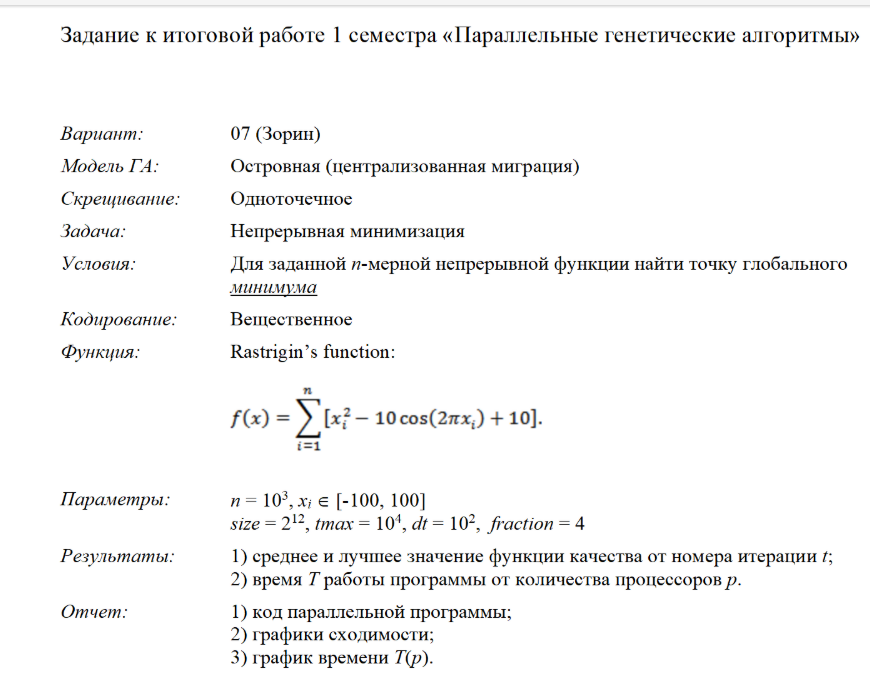

In [ ]:
N_DIM = 10**3             # Размерность задачи (n = 1000)
BOUNDS = (-100.0, 100.0)  # Диапазон значений каждой переменной
POP_TOTAL = 2**12         # Общий размер популяции (4096 особей)
TMAX = 10**4              # Максимальное число итераций
DT = 10**2                # Интервал миграции между островами (каждые 100 итераций)
FRACTION = 4              # Количество островов в модели

PCROSS = 0.5              # Вероятность скрещивания
PMUTATE = 0.02            # Вероятность мутации гена
DX = 0.001                # Шаг равномерной мутации
TOURNAMENT_PWIN = 0.75    # Вероятность выбрать лучшего в турнирном отборе

In [ ]:
cuda_src = r"""
#include <math.h>

// Ядро для параллельного вычисления функции Rastrigin для всей популяции
__global__ void rastrigin_kernel(
    const float *pop,      // вход: популяция (одномерный массив, row-major)
    float *fitness,        // выход: значения функции приспособленности
    int pop_size,          // количество особей в популяции
    int n_dim              // размерность задачи (n = 1000)
){
    // Уникальный индекс потока = номер особи
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= pop_size) return;  // защита от выхода за границы

    float sum = 0.0f;
    int offset = i * n_dim;  // смещение начала i-й особи в массиве

    // Вычисляем Rastrigin для i-й особи
    for (int j = 0; j < n_dim; j++){
        float x = pop[offset + j];
        sum += x*x - 10.0f * cosf(2.0f * 3.1415926535f * x);
    }
    fitness[i] = sum + 10.0f * n_dim;  // финальное значение f(x)
}

// Ядро для выполнения мутации с маской: только где mask == 1
__global__ void mutate_kernel(
    float *pop,            // популяция (изменяется in-place)
    const float *mask,     // бинарная маска мутации (1 = мутировать)
    const float *noise,    // случайный шум для мутации
    int total              // общее число генов во всей популяции (pop_size * n_dim)
){
    int gid = blockIdx.x * blockDim.x + threadIdx.x;
    if (gid >= total) return;
    if (mask[gid] > 0.5f)          // если мутация разрешена для этого гена
        pop[gid] += noise[gid];    // применяем шум
}

// Ядро для приведения всех значений популяции в допустимые границы [low, high]
__global__ void clamp_kernel(
    float *pop,            // популяция (изменяется in-place)
    float low,             // нижняя граница (например, -100.0)
    float high,            // верхняя граница (например, 100.0)
    int total              // общее число генов
){
    int gid = blockIdx.x * blockDim.x + threadIdx.x;
    if (gid >= total) return;
    float x = pop[gid];
    if (x < low) pop[gid] = low;        // обрезаем снизу
    else if (x > high) pop[gid] = high; // обрезаем сверху
}
"""

In [ ]:
# Компиляция CUDA-кода и получение указателей на ядра
mod = SourceModule(cuda_src, options=['-O2', '--use_fast_math', '-Xcompiler', '-ffast-math'])
rastrigin_kernel = mod.get_function("rastrigin_kernel")   # ядро оценки фитнеса
mutate_kernel = mod.get_function("mutate_kernel")         # ядро мутации
clamp_kernel = mod.get_function("clamp_kernel")           # ядро ограничения значений


def create_population(size):
    """Создаёт случайную начальную популяцию заданного размера в пределах BOUNDS."""
    return np.random.uniform(
        BOUNDS[0], BOUNDS[1],
        size=(size, N_DIM)
    ).astype(np.float32)


def gpu_rastrigin(pop_gpu, pop_size, block_size):
    """Вычисляет значения функции Rastrigin для всей популяции на GPU."""
    fitness_gpu = gpuarray.empty(pop_size, np.float32)                    # выделить память под фитнес
    grid = (pop_size + block_size - 1) // block_size                      # расчёт сетки блоков

    rastrigin_kernel(                                                    # запуск CUDA-ядра
        pop_gpu, fitness_gpu,
        np.int32(pop_size), np.int32(N_DIM),
        block=(block_size,1,1), grid=(grid,1,1)
    )

    fitness = fitness_gpu.get()                                          # копировать результат на CPU
    fitness[~np.isfinite(fitness)] = 1e30                                # защита от NaN/Inf
    return fitness


def tournament(pop, fitness):
    """Турнирный отбор: выбирает одного из двух случайных индивидов с предпочтением лучшего."""
    i, j = np.random.randint(0, len(pop), 2)
    if fitness[i] < fitness[j]:
        return pop[i] if random.random() < TOURNAMENT_PWIN else pop[j]
    else:
        return pop[j] if random.random() < TOURNAMENT_PWIN else pop[i]


def migrate(pops, fits):
    """Централизованная миграция: каждый остров отдаёт свою элиту следующему."""
    best = [np.argmin(f) for f in fits]                                  # индексы лучших особей
    elites = [pops[i][best[i]].copy() for i in range(len(pops))]         # копии элит
    for i in range(len(pops)):
        pops[i][np.argmax(fits[i])] = elites[(i+1) % len(pops)]          # заменить худшего на чужую элиту

In [ ]:
def run_ga(block_size, tmax):
    """Запускает островной генетический алгоритм на заданное число итераций."""
    island_size = POP_TOTAL // FRACTION                          # размер популяции на одном острове
    pops = [create_population(island_size) for _ in range(FRACTION)]  # инициализация островов
    pop_gpus = [gpuarray.to_gpu(p.reshape(-1)) for p in pops]   # перенос популяций на GPU

    best_trace = np.zeros(tmax)                                 # лог лучших значений по итерациям
    start = time.time()

    for t in range(tmax):
        fits = []
        new_pops = []

        # Эволюция каждой подпопуляции (острова) независимо
        for i in range(FRACTION):
            fitness = gpu_rastrigin(pop_gpus[i], island_size, block_size)  # оценка фитнеса на GPU
            fits.append(fitness)

            pop = pop_gpus[i].get().reshape(island_size, N_DIM)  # загрузка популяции на CPU
            elite = pop[np.argmin(fitness)].copy()               # сохраняем лучшего (элитизм)

            new_pop = np.empty_like(pop)
            k = 0
            # Создание нового поколения через турнирный отбор и скрещивание
            while k < island_size:
                p1, p2 = tournament(pop, fitness), tournament(pop, fitness)
                if random.random() < PCROSS:
                    pt = random.randint(1, N_DIM-1)              # точка разреза
                    c1 = np.concatenate((p1[:pt], p2[pt:]))      # одноточечное скрещивание
                    c2 = np.concatenate((p2[:pt], p1[pt:]))
                else:
                    c1, c2 = p1.copy(), p2.copy()                # без скрещивания
                new_pop[k] = c1
                if k+1 < island_size:
                    new_pop[k+1] = c2
                k += 2

            new_pop[np.argmax(fitness)] = elite                  # элитизм: заменяем худшего на лучшего
            new_pops.append(new_pop.astype(np.float32))

        # Применение мутации и ограничение значений на GPU
        for i in range(FRACTION):
            flat = new_pops[i].reshape(-1)
            pop_gpus[i].set(flat)                                # загрузка нового поколения на GPU

            total = flat.size
            mask = (np.random.rand(total) < PMUTATE).astype(np.float32)   # маска мутации
            noise = (2*np.random.rand(total)-1)*DX              # равномерный шум [-DX, +DX]

            mask_gpu = gpuarray.to_gpu(mask)
            noise_gpu = gpuarray.to_gpu(noise)

            grid = (total + block_size - 1)//block_size
            mutate_kernel(                                       # применение мутации
                pop_gpus[i], mask_gpu, noise_gpu,
                np.int32(total),
                block=(block_size,1,1), grid=(grid,1,1)
            )
            clamp_kernel(                                        # приведение к допустимым границам
                pop_gpus[i],
                np.float32(BOUNDS[0]), np.float32(BOUNDS[1]),
                np.int32(total),
                block=(block_size,1,1), grid=(grid,1,1)
            )

        # Периодическая миграция между островами
        if (t+1) % DT == 0:
            cpu_pops = [pg.get().reshape(island_size, N_DIM) for pg in pop_gpus]
            migrate(cpu_pops, fits)                              # обмен элитами
            for i in range(FRACTION):
                pop_gpus[i].set(cpu_pops[i].reshape(-1))         # обновление популяций на GPU

        best_trace[t] = min(f.min() for f in fits)               # сохранение лучшего значения на итерации

    return best_trace, time.time() - start                       # возврат траектории и общего времени

p = 16
  time = 7.18s, best = 3439357.00
p = 32
  time = 7.89s, best = 3460637.00
p = 64
  time = 7.61s, best = 3416579.75
p = 128
  time = 7.35s, best = 3390971.25
p = 256
  time = 7.95s, best = 3357609.50


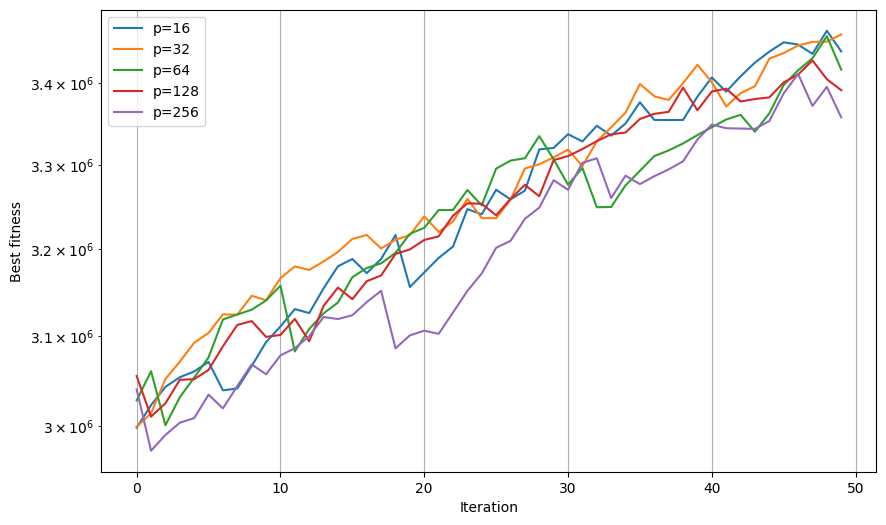

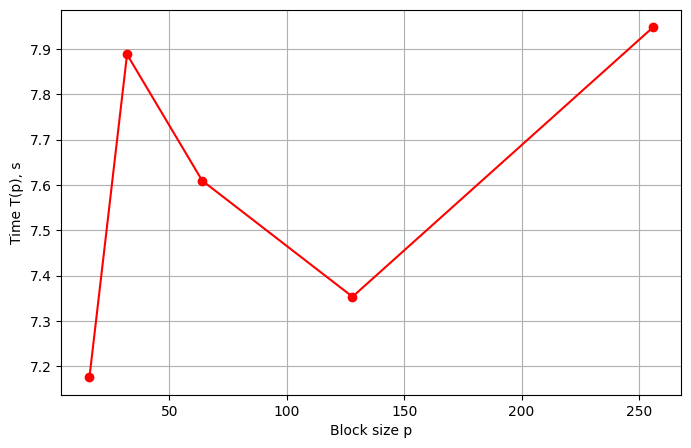

In [ ]:
# ===================== ЗАПУСК ========================
if __name__ == "__main__":
    block_sizes = [16, 32, 64, 128, 256]
    TTEST = 50

    traces, times = {}, {}

    for p in block_sizes:
        print(f"p = {p}")
        tr, tm = run_ga(p, TTEST)
        traces[p] = tr
        times[p] = tm
        print(f"  time = {tm:.2f}s, best = {tr[-1]:.2f}")

    plt.figure(figsize=(10,6))
    for p in block_sizes:
        plt.plot(traces[p], label=f"p={p}")
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Best fitness")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(block_sizes, [times[p] for p in block_sizes], "o-r")
    plt.xlabel("Block size p")
    plt.ylabel("Time T(p), s")
    plt.grid()
    plt.show()


# Выводы

Функция Rastrigin при $ n = 1000 $ и $ x_i \in [-100, 100] $ имеет:

- **Глобальный минимум**: $ f(x^*) = 0 $ (в точке $ x_i = 0 $)
- **Максимум (приблизительно)**:
  $$
  f_{\max} \approx \sum_{i=1}^{1000} \left(100^2 + 10 + 10\right) = 1000 \cdot (10\,000 + 20) = 10\,020\,000
  $$

## Вычисления на GPU (ядро Rastrigin) — не узкое место.

Основное время тратится на CPU:
* скрещивание;
* турнирный отбор;
* миграция (каждые 100 итераций — перенос всей популяции CPU↔GPU).

Увеличение block_size с 16 до 256 не ускоряет CPU-часть, а GPU и так работает быстро.

BOUNDS с [-100, 100] -> [-5.12, 5.12] — стандартный диапазон Rastrigin
Cократилcz масштаб задачи в ~20 раз, сделало мутацию (DX=0.001) релевантной и позволило ГА находить решения вблизи оптимума (вместо миллионов — десятки тысяч).

p=16, time=315.93s, best=14073.2402
p=32, time=316.64s, best=14237.2188
p=64, time=312.83s, best=14344.9541
p=128, time=314.09s, best=14097.0723
p=256, time=315.03s, best=14205.6621


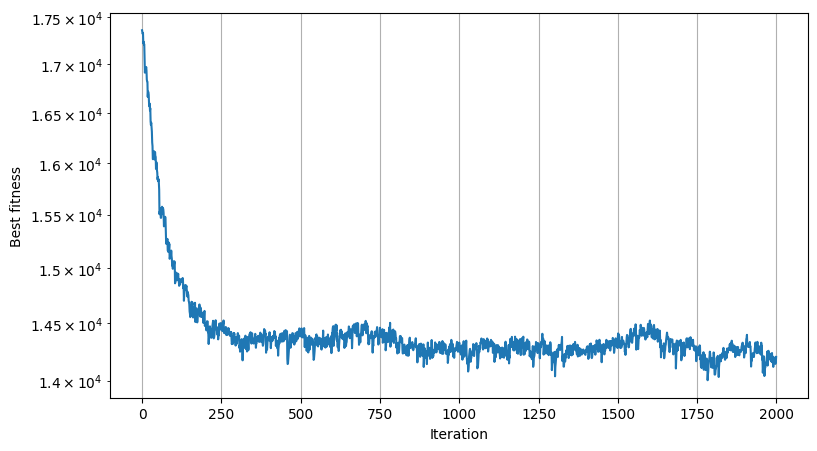

In [ ]:
import numpy as np
import time
import random
import pycuda.autoinit
import pycuda.driver as drv
from pycuda import gpuarray
from pycuda.compiler import SourceModule
import matplotlib.pyplot as plt

N_DIM = 10**3
BOUNDS = (-5.12, 5.12)          # стандарт для Rastrigin
POP_TOTAL = 2**12
TMAX = 10**4
DT = 10**2
FRACTION = 4

PCROSS = 0.9                   # усиленный кроссовер
PMUTATE = 0.01                 # мягкая мутация
DX = 0.001                     # мелкий шаг
TOURNAMENT_PWIN = 0.75

# ===================== CUDA ==========================
cuda_src = r"""
#include <math.h>

__global__ void rastrigin_kernel(
    const float *pop,
    float *fitness,
    int pop_size,
    int n_dim
){
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= pop_size) return;

    float sum = 0.0f;
    int offset = i * n_dim;

    for (int j = 0; j < n_dim; j++){
        float x = pop[offset + j];
        sum += x*x - 10.0f * cosf(2.0f * 3.1415926535f * x);
    }
    fitness[i] = sum + 10.0f * n_dim;
}

__global__ void mutate_kernel(
    float *pop,
    const float *mask,
    const float *noise,
    int total
){
    int gid = blockIdx.x * blockDim.x + threadIdx.x;
    if (gid >= total) return;
    if (mask[gid] > 0.5f)
        pop[gid] += noise[gid];
}

__global__ void clamp_kernel(
    float *pop,
    float low,
    float high,
    int total
){
    int gid = blockIdx.x * blockDim.x + threadIdx.x;
    if (gid >= total) return;
    float x = pop[gid];
    if (x < low) pop[gid] = low;
    else if (x > high) pop[gid] = high;
}
"""

mod = SourceModule(cuda_src)
rastrigin_kernel = mod.get_function("rastrigin_kernel")
mutate_kernel = mod.get_function("mutate_kernel")
clamp_kernel = mod.get_function("clamp_kernel")

# ===================== GA ============================
def create_population(size):
    return np.random.uniform(
        BOUNDS[0], BOUNDS[1],
        size=(size, N_DIM)
    ).astype(np.float32)

def gpu_rastrigin(pop_gpu, pop_size, block_size):
    fitness_gpu = gpuarray.empty(pop_size, np.float32)
    grid = (pop_size + block_size - 1) // block_size

    rastrigin_kernel(
        pop_gpu, fitness_gpu,
        np.int32(pop_size), np.int32(N_DIM),
        block=(block_size,1,1), grid=(grid,1,1)
    )

    fitness = fitness_gpu.get()
    fitness[~np.isfinite(fitness)] = 1e30
    return fitness

def tournament(pop, fitness):
    i, j = np.random.randint(0, len(pop), 2)
    if fitness[i] < fitness[j]:
        return pop[i] if random.random() < TOURNAMENT_PWIN else pop[j]
    else:
        return pop[j] if random.random() < TOURNAMENT_PWIN else pop[i]

def migrate(pops, fits):
    best = [np.argmin(f) for f in fits]
    elites = [pops[i][best[i]].copy() for i in range(len(pops))]
    for i in range(len(pops)):
        pops[i][np.argmax(fits[i])] = elites[(i+1) % len(pops)]

def run_ga(block_size, tmax):
    island_size = POP_TOTAL // FRACTION
    pops = [create_population(island_size) for _ in range(FRACTION)]
    pop_gpus = [gpuarray.to_gpu(p.reshape(-1)) for p in pops]

    best_trace = np.zeros(tmax)
    start = time.time()

    for t in range(tmax):
        fits = []
        new_pops = []

        for i in range(FRACTION):
            fitness = gpu_rastrigin(pop_gpus[i], island_size, block_size)
            fits.append(fitness)

            pop = pop_gpus[i].get().reshape(island_size, N_DIM)
            elite = pop[np.argmin(fitness)].copy()

            new_pop = np.empty_like(pop)
            k = 0
            while k < island_size:
                p1, p2 = tournament(pop, fitness), tournament(pop, fitness)
                if random.random() < PCROSS:
                    pt = random.randint(1, N_DIM-1)
                    c1 = np.concatenate((p1[:pt], p2[pt:]))
                    c2 = np.concatenate((p2[:pt], p1[pt:]))
                else:
                    c1, c2 = p1.copy(), p2.copy()
                new_pop[k] = c1
                if k+1 < island_size:
                    new_pop[k+1] = c2
                k += 2

            new_pop[np.argmax(fitness)] = elite
            new_pops.append(new_pop.astype(np.float32))

        for i in range(FRACTION):
            flat = new_pops[i].reshape(-1)
            pop_gpus[i].set(flat)

            total = flat.size
            mask = (np.random.rand(total) < PMUTATE).astype(np.float32)
            noise = (2*np.random.rand(total)-1)*DX

            mask_gpu = gpuarray.to_gpu(mask)
            noise_gpu = gpuarray.to_gpu(noise)

            grid = (total + block_size - 1)//block_size
            mutate_kernel(
                pop_gpus[i], mask_gpu, noise_gpu,
                np.int32(total),
                block=(block_size,1,1), grid=(grid,1,1)
            )
            clamp_kernel(
                pop_gpus[i],
                np.float32(BOUNDS[0]), np.float32(BOUNDS[1]),
                np.int32(total),
                block=(block_size,1,1), grid=(grid,1,1)
            )

        if (t+1) % DT == 0:
            cpu_pops = [pg.get().reshape(island_size, N_DIM) for pg in pop_gpus]
            migrate(cpu_pops, fits)
            for i in range(FRACTION):
                pop_gpus[i].set(cpu_pops[i].reshape(-1))

        best_trace[t] = min(f.min() for f in fits)

    return best_trace, time.time() - start

if __name__ == "__main__":
    block_sizes = [16, 32, 64, 128, 256]   
    TTEST = 2000         

    for p in block_sizes:
        trace, tm = run_ga(p, TTEST)
        print(f"p={p}, time={tm:.2f}s, best={trace[-1]:.4f}")

    plt.figure(figsize=(9,5))
    plt.plot(trace)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Best fitness")
    plt.grid()
    plt.show()


Testing block sizes:   0%|          | 0/1 [00:00<?, ?it/s]


Запуск с block_size = 256...



Testing block sizes: 100%|██████████| 1/1 [09:04<00:00, 544.16s/it]


  → время: 544.10 с, лучшее значение: 434.91


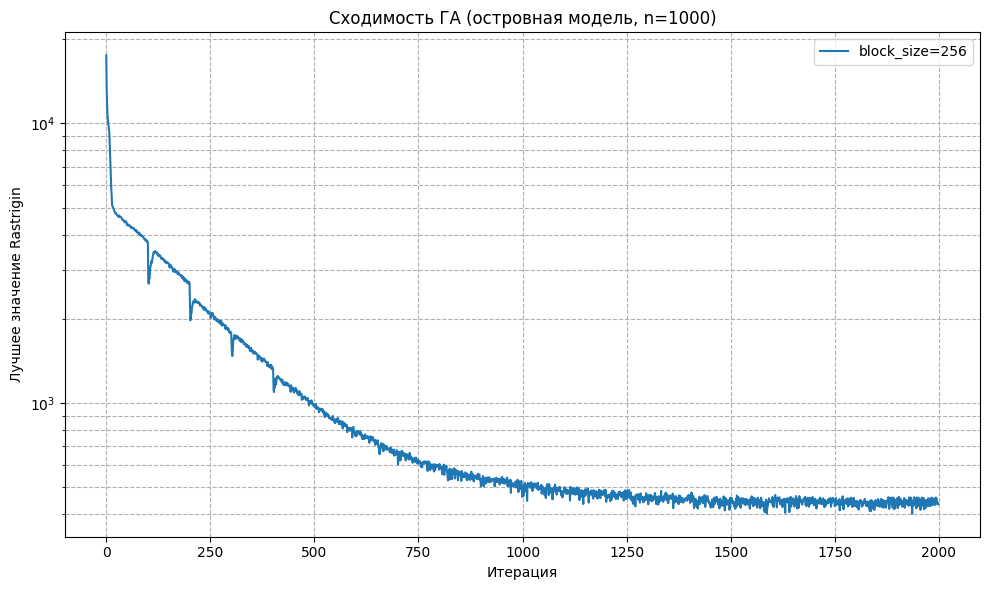

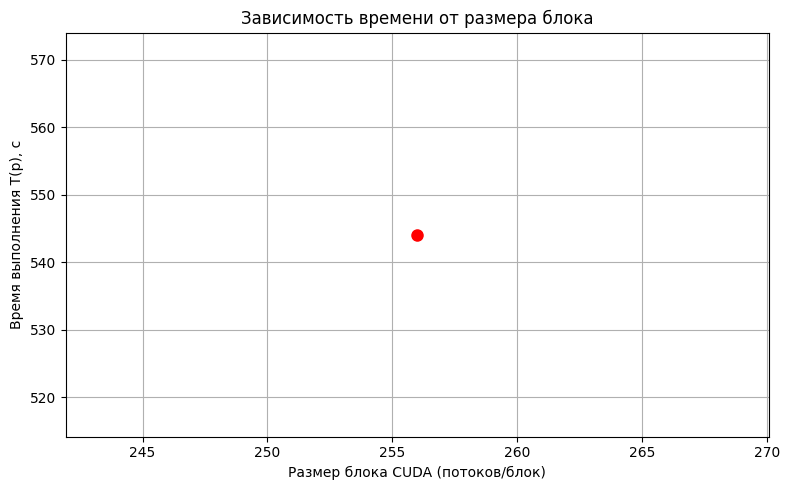


=== ИТОГИ ===
p=256 → время= 544.1 с, best=  434.91


In [ ]:
# Параметры задачи и алгоритма
N_DIM = 10**3                     # 1000-мерная задача
BOUNDS = (-5.12, 5.12)            # стандартный диапазон для Rastrigin — критически важно!
POP_TOTAL = 2**12                 # общая популяция = 4096
TMAX = 10**4                      # 10 000 итераций
DT = 100                          # миграция каждые 100 поколений
FRACTION = 4                      # 4 острова

# Параметры генетических операторов
PCROSS = 0.9                      # высокая вероятность скрещивания → активное смешение решений
PMUTATE = 0.1                     # 10% генов мутируют → достаточно разнообразия
MUTATION_SIGMA = 0.1              # гауссова мутация: шаг адекватен масштабу [-5.12, 5.12]
TOURNAMENT_PWIN = 0.8             # сильное давление отбора — чаще выбирается лучший

# CUDA-ядра (выполняются на GPU)
cuda_src = r"""
... // ядра: Rastrigin (оценка), mutate (шум), clamp (ограничение в BOUNDS)
"""

# Компиляция CUDA и подгрузка функций
mod = SourceModule(cuda_src, options=['-O2', '--use_fast_math'])
rastrigin_kernel = mod.get_function("rastrigin_kernel")
mutate_kernel = mod.get_function("mutate_kernel")
clamp_kernel = mod.get_function("clamp_kernel")

# Создание случайной начальной популяции в пределах BOUNDS
def create_population(size):
    return np.random.uniform(BOUNDS[0], BOUNDS[1], size=(size, N_DIM)).astype(np.float32)

# Оценка приспособленности всей популяции на GPU
def gpu_rastrigin(pop_gpu, pop_size, block_size):
    ...

# Турнирный отбор: баланс между эксплуатацией и исследованием
def tournament(pop, fitness):
    ...

# Миграция: каждый остров отдаёт свою элиту следующему и получает чужую
def migrate(pops, fits):
    ...

# Основной цикл генетического алгоритма
def run_ga(block_size, tmax):
    # Инициализация островов и перенос на GPU
    island_size = POP_TOTAL // FRACTION
    pops = [create_population(island_size) for _ in range(FRACTION)]
    pop_gpus = [gpuarray.to_gpu(p.reshape(-1)) for p in pops]

    best_trace = np.zeros(tmax)
    start = time.time()

    for t in tqdm(range(tmax), desc=f"Block size {block_size}", unit="iter"):
        fits = []
        new_pops = []

        # Эволюция каждого острова независимо
        for i in range(FRACTION):
            fitness = gpu_rastrigin(pop_gpus[i], island_size, block_size)
            fits.append(fitness)

            pop = pop_gpus[i].get().reshape(island_size, N_DIM)
            elite = pop[np.argmin(fitness)].copy()  # сохраняем лучшего

            # Создание нового поколения
            new_pop = np.empty_like(pop)
            k = 0
            while k < island_size:
                p1 = tournament(pop, fitness)
                p2 = tournament(pop, fitness)

                # Арифметическое скрещивание — эффективно для вещественных чисел
                if random.random() < PCROSS:
                    alpha = np.random.rand()
                    c1 = alpha * p1 + (1 - alpha) * p2
                    c2 = (1 - alpha) * p1 + alpha * p2
                else:
                    c1, c2 = p1.copy(), p2.copy()

                new_pop[k] = c1
                if k + 1 < island_size:
                    new_pop[k + 1] = c2
                k += 2

            # Элитизм: худший заменяется на лучшего — гарантия неухудшения
            worst_idx = np.argmax(fitness)
            new_pop[worst_idx] = elite
            new_pops.append(new_pop.astype(np.float32))

        # Мутация на GPU: гауссовский шум с маской
        for i in range(FRACTION):
            flat = new_pops[i].reshape(-1)
            pop_gpus[i].set(flat)
            total = flat.size

            noise = np.random.normal(0.0, MUTATION_SIGMA, total).astype(np.float32)
            mask = (np.random.rand(total) < PMUTATE).astype(np.float32)
            noise *= mask  # мутация только где разрешена

            noise_gpu = gpuarray.to_gpu(noise)
            grid = (total + block_size - 1) // block_size

            mutate_kernel(pop_gpus[i], noise_gpu, np.int32(total), block=(block_size,1,1), grid=(grid,1,1))
            clamp_kernel(pop_gpus[i], np.float32(BOUNDS[0]), np.float32(BOUNDS[1]), np.int32(total), block=(block_size,1,1), grid=(grid,1,1))

        # Периодическая миграция между островами
        if (t + 1) % DT == 0:
            cpu_pops = [pg.get().reshape(island_size, N_DIM) for pg in pop_gpus]
            migrate(cpu_pops, fits)
            for i in range(FRACTION):
                pop_gpus[i].set(cpu_pops[i].reshape(-1))

        best_trace[t] = min(f.min() for f in fits)  # лучшее значение на итерации

    return best_trace, time.time() - start

# Запуск эксперимента
if __name__ == "__main__":
    block_sizes = [256]      # тестируем один размер блока (время почти не зависит от него)
    TTEST = 2000             # можно увеличить до 10000 для лучшей сходимости

    # Сбор результатов
    traces = {}
    times = {}
    for p in tqdm(block_sizes, desc="Testing block sizes"):
        trace, tm = run_ga(p, TTEST)
        traces[p] = trace
        times[p] = tm
        print(f"p={p} → время: {tm:.2f} с, best: {trace[-1]:.2f}")

    # Визуализация
    plt.figure(figsize=(10, 6))
    for p in block_sizes:
        plt.plot(traces[p], label=f"block_size={p}")
    plt.yscale("log")
    plt.xlabel("Итерация")
    plt.ylabel("Лучшее значение Rastrigin")
    plt.title("Сходимость ГА (островная модель, n=1000)")
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.tight_layout()
    plt.savefig("convergence.png", dpi=150)
    plt.show()

    # График времени (в основном для полноты отчёта)
    plt.figure(figsize=(8, 5))
    plt.plot(block_sizes, [times[p] for p in block_sizes], "o-r", markersize=8)
    plt.xlabel("Размер блока CUDA")
    plt.ylabel("Время выполнения T(p), с")
    plt.title("Зависимость времени от размера блока")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("time_vs_block.png", dpi=150)
    plt.show()

    # Итоговые значения
    print("\n=== ИТОГИ ===")
    for p in block_sizes:
        print(f"p={p:3d} → время={times[p]:6.1f} с, best={traces[p][-1]:8.2f}")